/tmp/ipykernel_725796/2783205658.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="2y")
[*********************100%***********************]  1 of 1 completed


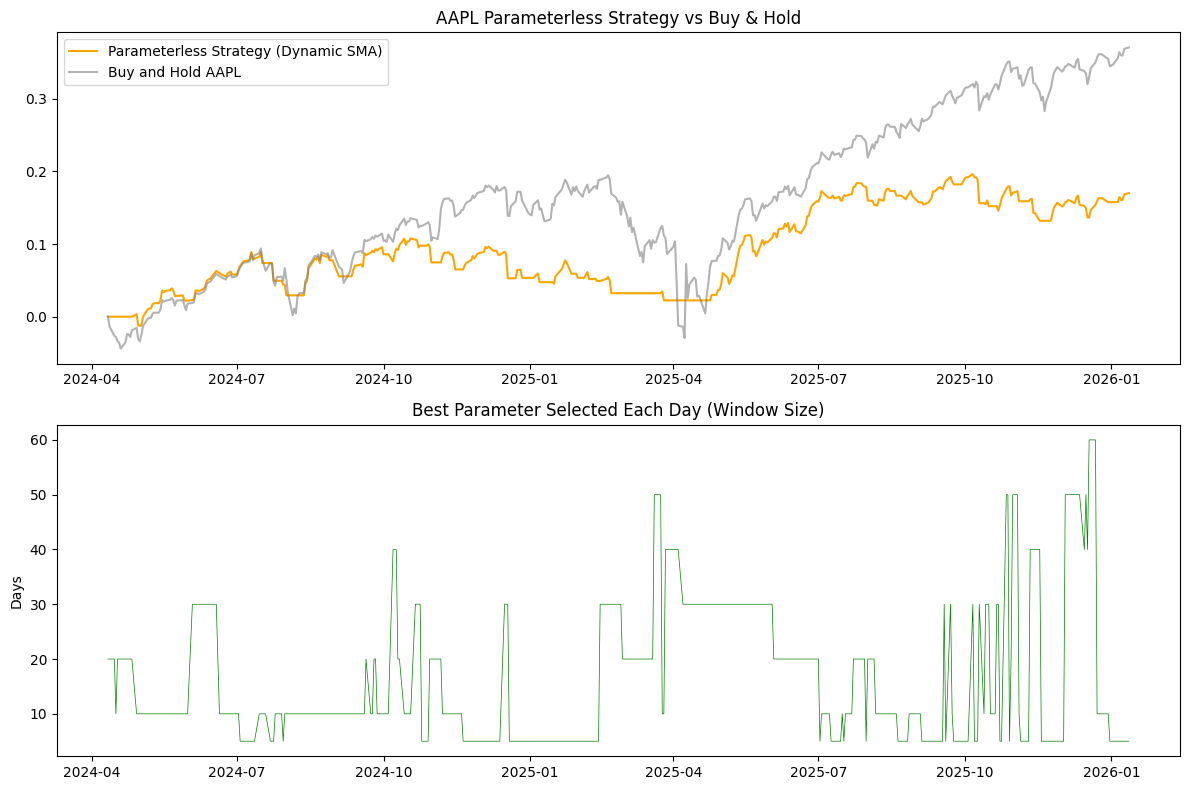

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 下载苹果公司过去两年的数据（多买一年是为了给观察窗口留出空间）
ticker = "SPY"
data = yf.download(ticker, period="2y")
# 适配 yfinance 新版本的多级索引
prices = data['Close'][ticker] if isinstance(data.columns, pd.MultiIndex) else data['Close']

# 2. 定义回测逻辑函数
def get_performance(price_series, window):
    # 计算简单均线
    sma = price_series.rolling(window).mean()
    # 策略：价格 > 均线买入，否则空仓
    signal = (price_series > sma).shift(1).fillna(0)
    returns = price_series.pct_change() * signal
    return returns.sum()

# 3. 步进优化 (Walk-Forward Optimization)
lookback = 60  # 动态观察过去60天
param_choices = [5, 10, 20, 30, 40, 50, 60]
strategy_returns = []
selected_params = []

# 从第60天开始，逐日滚动
for t in range(lookback, len(prices)):
    past_window = prices.iloc[t-lookback : t]
    
    # 寻找当前表现最好的参数
    best_p = max(param_choices, key=lambda p: get_performance(past_window, p))
    selected_params.append(best_p)
    
    # 使用该参数计算今天的收益
    current_sma = prices.iloc[t-best_p : t].mean()
    signal = 1 if prices.iloc[t-1] > current_sma else 0
    daily_ret = prices.pct_change().iloc[t] * signal
    strategy_returns.append(daily_ret)

# 4. 结果整理
results = pd.Series(strategy_returns, index=prices.index[lookback:])
cum_strategy = (1 + results).cumprod() - 1
cum_buy_hold = (1 + prices.iloc[lookback:].pct_change().fillna(0)).cumprod() - 1

# 5. 可视化
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(cum_strategy, label='Parameterless Strategy (Dynamic SMA)', color='orange')
plt.plot(cum_buy_hold, label='Buy and Hold AAPL', color='gray', alpha=0.6)
plt.title(f'AAPL Parameterless Strategy vs Buy & Hold')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(pd.Series(selected_params, index=prices.index[lookback:]), color='green', lw=0.5)
plt.title('Best Parameter Selected Each Day (Window Size)')
plt.ylabel('Days')
plt.tight_layout()
plt.show()